<a href="https://colab.research.google.com/github/sydas13/ML_Lab_Codes/blob/main/Question12.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import files

In [2]:
import pandas as pd
import numpy as np
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder, OneHotEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import SGD, Adam
import matplotlib.pyplot as plt
import itertools

In [3]:
uploaded = files.upload()

Saving Iris.csv to Iris.csv


In [4]:
df = pd.read_csv("Iris.csv")

X = df[['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm']].values
y = df['Species'].values

In [5]:
label_encoder = LabelEncoder()
y_integer = label_encoder.fit_transform(y)

onehot_encoder = OneHotEncoder(sparse_output=False)
y_encoded = onehot_encoder.fit_transform(y_integer.reshape(-1, 1))

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.3, random_state=42, stratify=y_integer
)

In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
output_classes = y_encoded.shape[1]

In [9]:
# 2. Define Model Training and Evaluation Function

def train_and_evaluate_mlp(
    hidden_layers,
    iterations, # epochs
    learning_rate,
    loss_function,
    activation_function,
    optimizer_name
):
    """
    Creates, compiles, trains, and evaluates an MLP model
    with the given hyperparameters.
    """
    print(f"\n Testing Configuration")
    print(f"  Hidden Layers: {hidden_layers}, Iterations: {iterations}, LR: {learning_rate}")
    print(f"  Loss: {loss_function}, Activation: {activation_function}, Optimizer: {optimizer_name}")

    # Build the model
    model = Sequential()

    # Input layer and first hidden layer
    model.add(Dense(10, input_dim=X_train_scaled.shape[1], activation=activation_function))

    # Add specified number of hidden layers (each with 10 neurons for simplicity)
    for _ in range(hidden_layers - 1): # Start from the second layer
        model.add(Dense(10, activation=activation_function))

    # Output layer: 'softmax' for multi-class classification
    # 'softmax' converts outputs into a probability distribution
    model.add(Dense(output_classes, activation='softmax'))

    # Select and configure the optimizer
    if optimizer_name == 'GD':
        # Use SGD without momentum for a more basic 'GD' approach
        optimizer = SGD(learning_rate=learning_rate, momentum=0.0)
    elif optimizer_name == 'SGD':
        # Use SGD with a typical momentum value
        optimizer = SGD(learning_rate=learning_rate, momentum=0.9)
    elif optimizer_name == 'Adam':
        optimizer = Adam(learning_rate=learning_rate)
    else:
        raise ValueError("Invalid optimizer name")

    # Compile the model
    model.compile(
        loss=loss_function,
        optimizer=optimizer,
        metrics=['accuracy']
    )

    # Train the model
    # Use validation_split to get an internal validation set for the curve plots
    history = model.fit(
        X_train_scaled,
        y_train,
        epochs=iterations,
        batch_size=32, # Batch size for training
        verbose=0, # Suppress training output
        validation_split=0.2 # 20% of training data for validation curves
    )

    # 3. Evaluate and Illustrate

    # Predict on the test data
    y_pred_probs = model.predict(X_test_scaled, verbose=0)
    # Convert probabilities to class labels (index of the highest probability)
    y_pred = np.argmax(y_pred_probs, axis=1)
    y_true = np.argmax(y_test, axis=1)

    # Calculate Performance Metrics
    metrics = {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Precision (Macro)': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'Recall (Macro)': recall_score(y_true, y_pred, average='macro', zero_division=0),
        'F1-Score (Macro)': f1_score(y_true, y_pred, average='macro', zero_division=0)
    }

    print("\n[Performance Metrics on Test Set]")
    for metric, value in metrics.items():
        print(f"  {metric}: {value:.4f}")

    # Plotting Curves (Loss and Accuracy)

    # Create the Plotting function
    def plot_curves(history, config_name):
        fig, ax = plt.subplots(1, 2, figsize=(14, 5))

        # Loss Curve
        ax[0].plot(history.history['loss'], label='Training Loss')
        ax[0].plot(history.history['val_loss'], label='Validation Loss')
        ax[0].set_title(f'Loss Curve\n{config_name}')
        ax[0].set_xlabel('Epoch')
        ax[0].set_ylabel('Loss')
        ax[0].legend()

        # Accuracy Curve
        ax[1].plot(history.history['accuracy'], label='Training Accuracy')
        ax[1].plot(history.history['val_accuracy'], label='Validation Accuracy')
        ax[1].set_title(f'Accuracy Curve\n{config_name}')
        ax[1].set_xlabel('Epoch')
        ax[1].set_ylabel('Accuracy')
        ax[1].legend()

        plt.tight_layout()
        plt.show()

    config_name = f"L{hidden_layers}, E{iterations}, LR{learning_rate}, {loss_function}, {activation_function}, {optimizer_name}"
    plot_curves(history, config_name)

    # 4. Observe Weights (Illustrative Example)
    # Due to the complexity and size of weights, we'll observe only the
    # initial layer's weights for an illustration.

    # Get weights from the first layer
    weights_L1, biases_L1 = model.layers[0].get_weights()

    print("\n[Illustrative Weight Observation - First Layer]")
    print(f"  Weights shape (Features x Neurons): {weights_L1.shape}")
    print(f"  Biases shape (Neurons): {biases_L1.shape}")
    print(f"  Mean Absolute Weight Value: {np.mean(np.abs(weights_L1)):.4f}")

    # This value gives a sense of the learned magnitude of the weights.

Starting MLP Hyperparameter Comparison...

 Testing Configuration
  Hidden Layers: 5, Iterations: 200, LR: 0.01
  Loss: categorical_crossentropy, Activation: relu, Optimizer: Adam


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



[Performance Metrics on Test Set]
  Accuracy: 0.9111
  Precision (Macro): 0.9155
  Recall (Macro): 0.9111
  F1-Score (Macro): 0.9107


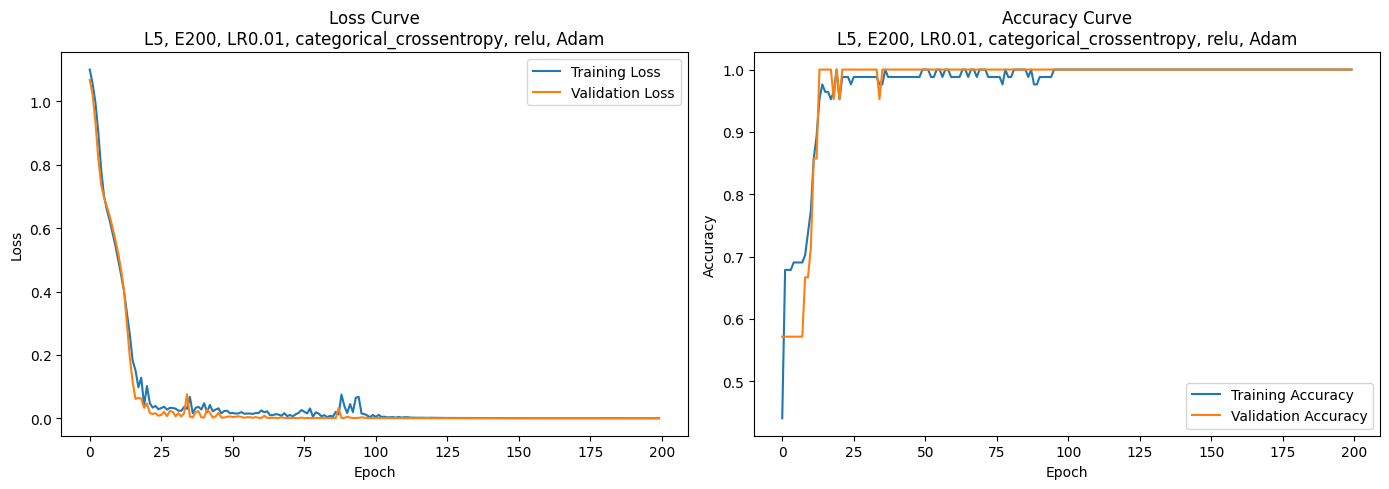


[Illustrative Weight Observation - First Layer]
  Weights shape (Features x Neurons): (4, 10)
  Biases shape (Neurons): (10,)
  Mean Absolute Weight Value: 0.3667

 Testing Configuration
  Hidden Layers: 5, Iterations: 400, LR: 0.01
  Loss: categorical_crossentropy, Activation: relu, Optimizer: Adam


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



[Performance Metrics on Test Set]
  Accuracy: 0.9333
  Precision (Macro): 0.9345
  Recall (Macro): 0.9333
  F1-Score (Macro): 0.9333


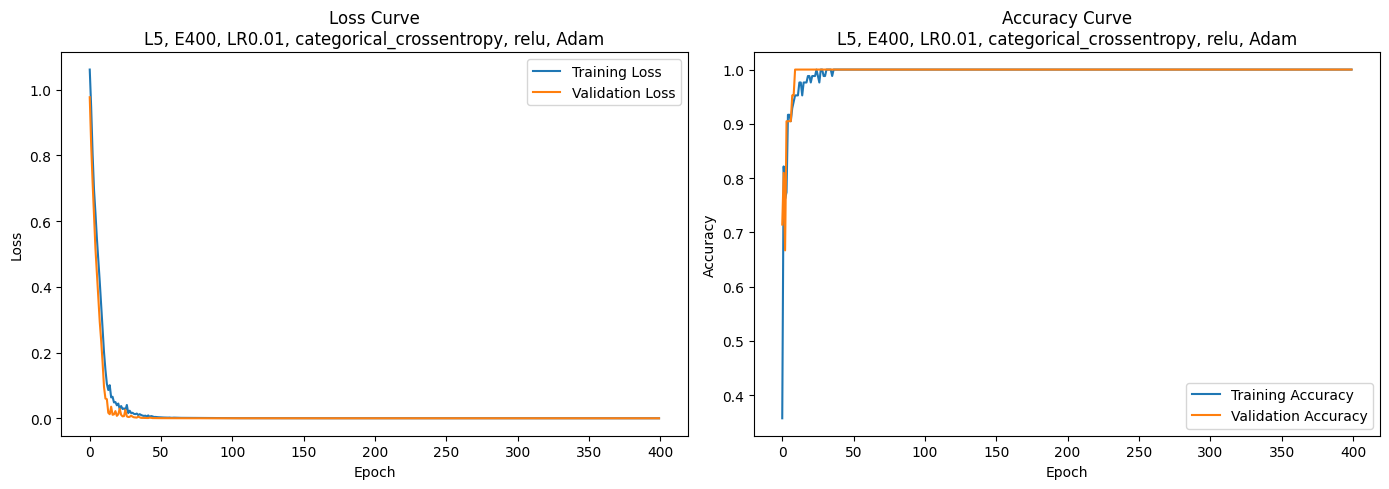


[Illustrative Weight Observation - First Layer]
  Weights shape (Features x Neurons): (4, 10)
  Biases shape (Neurons): (10,)
  Mean Absolute Weight Value: 0.4598

 Testing Configuration
  Hidden Layers: 5, Iterations: 200, LR: 0.01
  Loss: categorical_crossentropy, Activation: tanh, Optimizer: Adam


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



[Performance Metrics on Test Set]
  Accuracy: 0.9111
  Precision (Macro): 0.9298
  Recall (Macro): 0.9111
  F1-Score (Macro): 0.9095


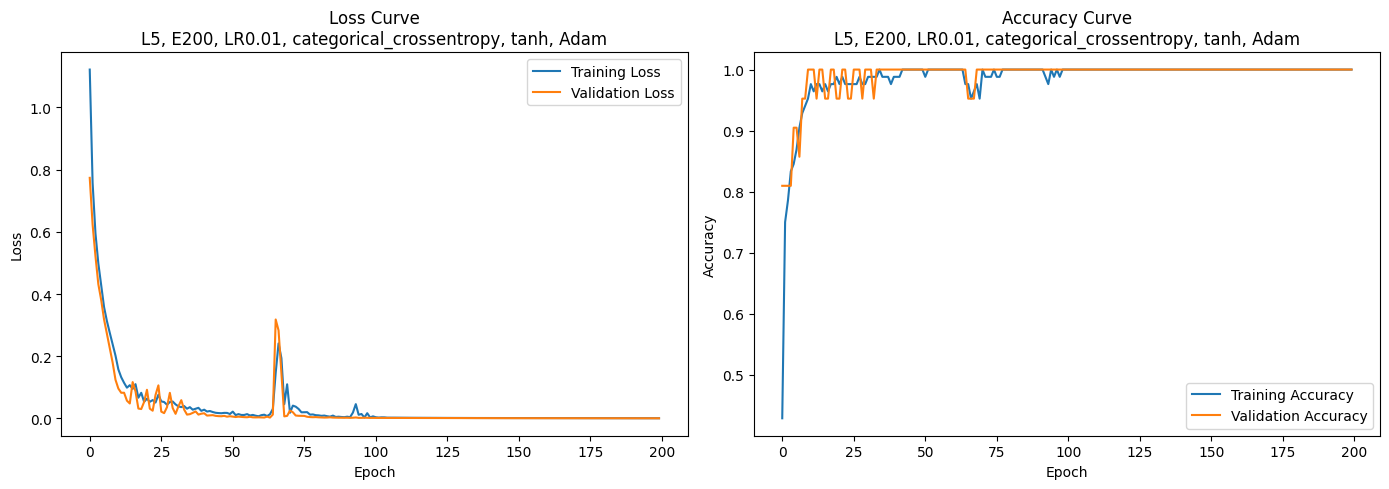


[Illustrative Weight Observation - First Layer]
  Weights shape (Features x Neurons): (4, 10)
  Biases shape (Neurons): (10,)
  Mean Absolute Weight Value: 0.3521

 Testing Configuration
  Hidden Layers: 5, Iterations: 200, LR: 0.01
  Loss: mse, Activation: relu, Optimizer: Adam


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



[Performance Metrics on Test Set]
  Accuracy: 0.8889
  Precision (Macro): 0.8981
  Recall (Macro): 0.8889
  F1-Score (Macro): 0.8878


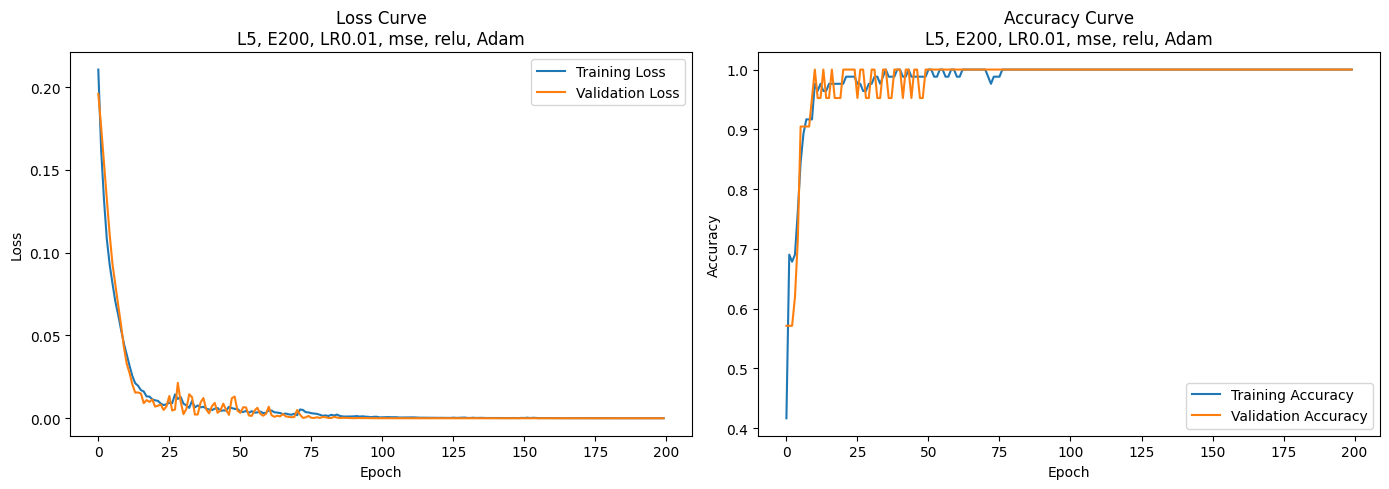


[Illustrative Weight Observation - First Layer]
  Weights shape (Features x Neurons): (4, 10)
  Biases shape (Neurons): (10,)
  Mean Absolute Weight Value: 0.4521

 Testing Configuration
  Hidden Layers: 5, Iterations: 200, LR: 0.01
  Loss: categorical_crossentropy, Activation: relu, Optimizer: SGD


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)



[Performance Metrics on Test Set]
  Accuracy: 0.9556
  Precision (Macro): 0.9608
  Recall (Macro): 0.9556
  F1-Score (Macro): 0.9554


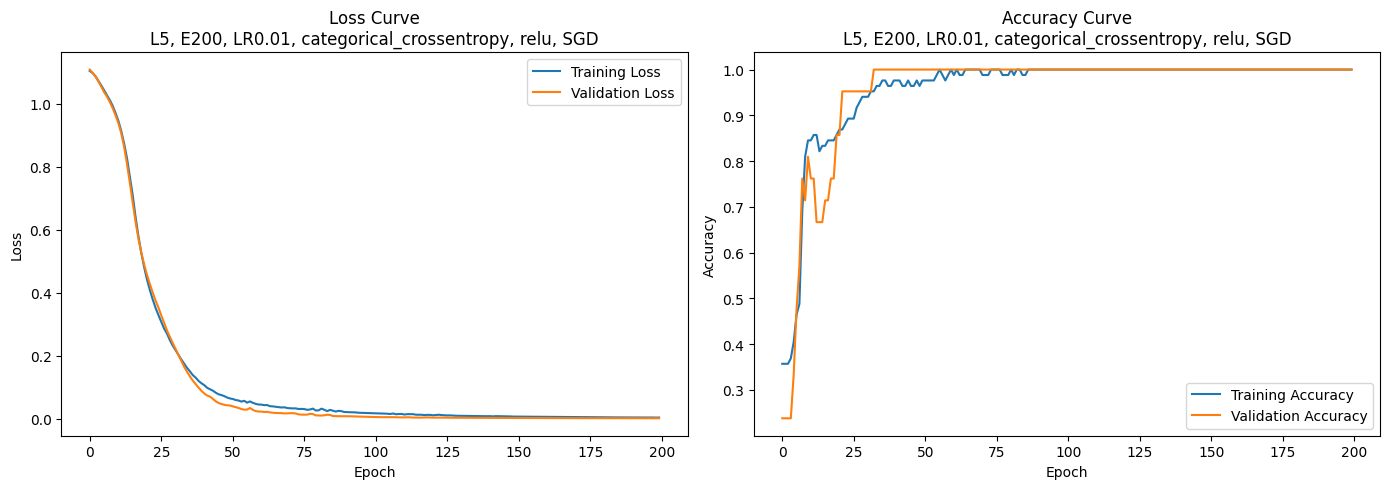


[Illustrative Weight Observation - First Layer]
  Weights shape (Features x Neurons): (4, 10)
  Biases shape (Neurons): (10,)
  Mean Absolute Weight Value: 0.4132

MLP Hyperparameter Comparison Complete.


In [10]:
#  5. Define Hyperparameters to Test

# Parameters requested by the user
hidden_layers = [5] # Number of hidden layers (requested 5)
iterations = [200, 400] # Epochs (requested 200 to 400)
learning_rate = 0.01 # A fixed rate for simplicity in this large test matrix

# Loss functions: MSE (Mean Squared Error), Categorical Crossentropy (for OHE labels)
loss_functions = ['mse', 'categorical_crossentropy']
# Note: For multi-class classification with one-hot encoded labels,
# 'categorical_crossentropy' is the standard, while 'mse' is an alternative.

# Activation functions (for hidden layers)
activation_functions = ['sigmoid', 'tanh', 'relu']

# Optimizers
optimizers = ['SGD', 'Adam'] # Using 'GD' will be represented by SGD with momentum=0.0

# Create all combinations for a limited test
# We will select a few key combinations instead of all 3 * 2 * 3 * 2 = 36 combinations
# to keep the output manageable and execution time short.

test_combinations = [
    # Baseline: Best practices for a fast learning/stable model
    (5, 200, 0.01, 'categorical_crossentropy', 'relu', 'Adam'),

    # High Iterations: Check for overfitting/convergence
    (5, 400, 0.01, 'categorical_crossentropy', 'relu', 'Adam'),

    # Alternative Activation: Tanh
    (5, 200, 0.01, 'categorical_crossentropy', 'tanh', 'Adam'),

    # Alternative Loss: MSE
    (5, 200, 0.01, 'mse', 'relu', 'Adam'),

    # Alternative Optimizer: SGD (with momentum)
    (5, 200, 0.01, 'categorical_crossentropy', 'relu', 'SGD'),
]

# 6. Run the Tests

# Add a reminder about the user-specified benefit of multiprogramming
# as an analogy for running multiple configurations.
# Running these tests sequentially is analogous to single-program execution,
# whereas for real-world hyperparameter tuning, parallel execution would offer
# superior **CPU utilization** and **responsiveness**, similar to the benefits of
# multiprogramming you noted on 2025-05-03.

print("Starting MLP Hyperparameter Comparison...")

for config in test_combinations:
    (layers, epochs, lr, loss, activation, optimizer) = config
    train_and_evaluate_mlp(layers, epochs, lr, loss, activation, optimizer)

print("\nMLP Hyperparameter Comparison Complete.")